## Section B
### Heart disease

#### Libraries

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

#### Importing and Preparing Dataset

##### Importing
We're using a data set UC Irvine Machine Learning Repository on heart disease found here:
https://archive.ics.uci.edu/dataset/45/heart+disease

We used the processed Cleveland heart disease database which we turned into a csv file and read below.

In [2]:
# read the cleveland.csv file to DataFrame heartDisease
heartDisease = pd.read_csv('cleveland.csv')
print(type(heartDisease))

<class 'pandas.core.frame.DataFrame'>


##### Information on the dataset
The dataset has 13 features:

1. (age)       
2. (sex)       
3. (cp)        
4. (trestbps)  
5. (chol)      
6. (fbs)       
7. (restecg)   
8. (thalach)   
9. (exang)     
10. (oldpeak)   
11. (slope)     
12. (ca)        
13. (thal)

and a value (num), 0 to 4, which refers to the presence of heart disease in a patient (0 being no prescence).

##### Preparing the data
We have a panda dataframe of the heart disease data, however to be able to create a neural network we need to clean the data. There is some missing data which needs to be removed.

In [3]:
# removing missing data (it becaomes NaN)
heartDiseaseData = heartDisease[~heartDisease.isin(['?'])]

In [4]:
# dropping rows with NaN
heartDiseaseData = heartDiseaseData.dropna(axis=0)

##### Preparing and Splitting the Data
We are now sorting the data so that we can use it to build a neural network.

In [5]:
# making the data numeric - needed for later
heartDiseaseData = heartDiseaseData.apply(pd.to_numeric)

We need to seperate the data into the its features and target. The neural network will use the features to predict the presence of heart disease (the target). 

In [6]:
# seprating the data into features, X, and target, y.
X = heartDiseaseData.drop(columns={'num'})
y = heartDiseaseData['num']

print(X.shape)
print(y.shape)

(297, 13)
(297,)


We now split our data into training and test data. We fit our model using the training data and then use the test data to see the accuracy of the model on unseen data. Here we are using 75% of the data for training and the remaining for testing.

In [7]:
from sklearn.model_selection import train_test_split

# splitting into test and train data
X_train_notStandardised, X_test_notStandardised, y_train, y_test = train_test_split(X, y, test_size = 0.25, train_size = 0.75, stratify=y, random_state=42)

print(X_train_notStandardised.shape)
print(X_test_notStandardised.shape)

print()
print(y_train.shape)
print(y_test.shape)

(222, 13)
(75, 13)

(222,)
(75,)


The features have different scales meaning that some features dominate more in the learning process, which can lead to a poor model with overfitting. Therefore we normalise our data using mean normalistaion so that the inputs are more balanced and easier for the model to learn.

We put the the features data through this formula:

$\text{new value} = \frac{\text{value - mean}}{\text{standard deviation}}$

So that it has a mean of 0 and standard deviation of 1.

In [8]:
from sklearn.preprocessing import StandardScaler

# mean normalisation
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train_notStandardised)
X_test = scalar.transform(X_test_notStandardised)

#### Building the Neural Network

Now we use our data to build and train a neural network model, which takes in features as an input outputs a number relating to the presence of heart disease.

##### Cost
To compute the cost, we used the `log_loss` function from `sklearn`, which uses the formula below to calculate the logistic regression/cross-entropy loss of the whole set/model.


$$L_{\log}(Y, P) = -\log \operatorname{Pr}(Y|P) = - \frac{1}{N} \sum_{i=0}^{N-1} \sum_{k=0}^{K-1} y_{i,k} \log p_{i,k}$$


where $y_{i,k} \in \{\{1,0,0,0,0\}, \{0,1,0,0,0\}, ..., \{0,0,0,0,1\}\}$ and $k \in \{0,1,2,3,4\}$ is the label, i.e. Y is the indicator matrix and $y_{i,k} = 1$ for a sample $i$ with label $k$,
and let $P$ be the matrix of probability estimates, with $p_{i,k} = \operatorname{Pr}(y_{i,k} = 1)$

We use our `compute_cost` function later on to show us the cost of the test data.

In [9]:
from sklearn.metrics import log_loss

def compute_cost(model, X, y_true):
    """
    Arguments:
    model - our model that were training
    X - array of the input values
    y - array of the actual output values we want to predict


    Returns:
    cost - a float which is the cross-entropy cost
    """

    # calculate the predicted probabilities
    y_pred = model.predict_proba(X)

    # compute the vector of losses by computing the cross-entropy loss element-wise
    # https://scikit-learn.org/stable/modules/model_evaluation.html#log-loss
    losses = log_loss(y_true, y_pred)

    return losses


##### The Model

We use `MLPClassifier` (Multi Layer Perceptron Classifier) from `sklearn` to build a neural network model. It is a supervised learning algorithm, which trains on a given dataset (our heart disease training data), to learn a function $f: R^{13} \rightarrow \{0, 1, 2, 3, 4\}$. We have an input of 13 features (which have been normalised), and then a scalar output between 0 and 4 relating to the presence of heart disease (0 being no presence).

We use the `sgd` solver, which is a stochastic gradient optimiser, very simialar task A3/4 and converges relatively quickly. Then for our activation function for the hidden layer(s), we use `relu` (rectified linear unit function) - $f(x) = max(x, 0)$ since it allows our model to learn faster.

The `build_model` function that we have have made, enables us to create a neural network with 3 hyperparameters:
1. `layerSize` - the size and number of hidden layers affecting the complexity of the neural network
2. `alphaValue` - the strength of the regularisation (it uses L2 regularisation - explained later)
3. `learningRate` - the constant learning rate of the solver, which controls the step-size when updating weights


![](MA124_NeuralNetDiag.png)


An example of what a neural network of the heart disease data could look like.
Each line has its own weight/parameter that needs to be learnt when we train the data.

In [10]:
from sklearn.neural_network import MLPClassifier

# model (neural network - classifier)
def build_model(layerSize=(100,), alphaValue=0.0001, learningRate=0.00001):
    """
    Arguments (hyperparameters):
    layerSize - array-like of the size of each hidden layer, default=(100,)
    alphaValue - a float of the L@ regularisation strength, default=0.0001
    learningRate - a float of the constant learning rate, default=0.00001
    
    Returns:
    model_unfitted - the MLPClassifier model which has not been trained yet
    """
    model_unfitted = MLPClassifier(hidden_layer_sizes=layerSize, activation='relu', solver='sgd', alpha=alphaValue, batch_size=5, learning_rate='constant', learning_rate_init=learningRate, 
                                    shuffle=True, random_state=42, tol=1e-3, verbose=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False)
    
    
    return model_unfitted


##### Train the model

We train the model using `partial_fit` in batches of 5 samples from `X_train` and `y_train`. We use batches so that we can train the model more efficiently. Once the model has been trained through the 44 batches, we record accuracy and cost of the training and test data, which can be used later to view the effectiveness of the model. This is repeated for a chosen number of epochs/iterations, so the model is retrained a chosen number of times.

We then can use the `plotAccuracy_model` and `plotCost_model` functions to view the data we collected. These graphs can then be analysed to see the accuracy of the model and if its overfitting or underfitting at all. Parameters can then be changed to improve the model e.g. the size of the regulisation term. We will actually use `plot_model`, which plots both the accuracy and cost graphs side by side.


In [11]:
# calulating number of batches, when using a batch size of 5
X_train.shape[0]

222

So we are training each iteration 44 batches, which each include 5 samples from the training data, `X_train`.

In [12]:
from sklearn.base import clone

# train model
def train_model(model_unfitted, maxEpochs=60, printInfo = True):
    """
    Arguments:
    model_unfitted - a MLPClassifier model that has not been trained yet
    maxEpochs - an integrer of the maximum number iterations/times we want to train the model
    printInfo - Boolean for if we print the accuracy and cost of the train and test data each epoch
    
    Returns:
    model - the now trained model
    epochs - an array of [1, 2, ... , maxEpoch]
    trainAccuracy_Arr - an array of accuracy of the training data at each epoch
    testAccuracy_Arr - an array of accuracy of the test data at each epoch
    trainCost_Arr - an array of cost of the training data at each epoch
    testCost_Arr - an array of cost of the test data at each epoch
    """

    # variables
    epochs = np.arange(1, maxEpochs+1)
    trainAccuracy_Arr = []
    trainCost_Arr = []
    testAccuracy_Arr = []
    testCost_Arr = []

    # model (unfitted) - making unfitted if it already has been
    model = clone(model_unfitted)

    for i in range(1, maxEpochs+ 1):
        # train model (1 iteration/epoch)
        for j in range(44):
            # batches of 5 samples
            X_batch = X_train[j*5:(j+1)*5]
            y_batch = y_train[j*5:(j+1)*5]

            model.partial_fit(X_batch, y_batch, np.unique(y_train))

        # get accuracy of training data
        trainAccuracy = model.score(X_train, y_train)
        trainAccuracy_Arr += [trainAccuracy]
        # get cost of training data
        trainCost = model.loss_
        trainCost_Arr += [trainCost]

        # get accuracy of test data
        testAccuracy = model.score(X_test, y_test)
        testAccuracy_Arr += [testAccuracy]
        # get cost of test data
        testCost = compute_cost(model, X_test, y_test)
        testCost_Arr += [testCost]

        if printInfo == True:
            # return info
            print("\nepoch:", i)
            print("loss:", trainCost)
            print("accuracy:", trainAccuracy)
            print("test loss:", testCost)
            print("test accuracy:",testAccuracy)

    return model, epochs, trainAccuracy_Arr, testAccuracy_Arr, trainCost_Arr, testCost_Arr
    

In [13]:
# plotting accuracy of training data vs test data
def plotAccuracy_model(epochs, trainAccuracy_Arr, testAccuracy_Arr):
    """
    Arguments:
    epochs - an array of 1, 2, ..., maxEpoch
    trainAccuracy_Arr - an array of accuracy of the training data at each epoch
    testAccuracy_Arr - an array of accuracy of the test data at each epoch

    Returns:
    A graph of accuracy, of training and test data, against epochs
    """

    plt.plot(epochs, trainAccuracy_Arr, label='Train data')
    plt.plot(epochs, testAccuracy_Arr, label='Test data')
    plt.title('Model Accuracy')
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.legend()
    plt.show()

In [14]:
# plotting cost of training data vs test data
def plotLoss_model(epochs, trainCost_Arr, testCost_Arr):
    """
    Arguments:
    epochs - an array of 1, 2, ..., maxEpoch
    trainCost_Arr - an array of cost of the training data at each epoch
    testCost_Arr - an array of cost of the test data at each epoch

    Returns:
    A graph of cost, of training and test data, against epochs
    """

    plt.plot(epochs, trainCost_Arr, label='Train data')
    plt.plot(epochs, testCost_Arr, label='Test data')
    plt.title('Model Loss')
    plt.xlabel('epochs')
    plt.ylabel('cost')
    plt.legend()
    plt.show()

In [15]:
# plotting both accuracy and cost graphs of traing vs test data using subplots
def plot_model(epochs, trainAccuracy_Arr, testAccuracy_Arr, trainCost_Arr, testCost_Arr):
    """
    Arguments:
    epochs - an array of 1, 2, ..., maxEpoch
    trainAccuracy_Arr - an array of accuracy of the training data at each epoch
    testAccuracy_Arr - an array of accuracy of the test data at each epoch
    trainCost_Arr - an array of cost of the training data at each epoch
    testCost_Arr - an array of cost of the test data at each epoch

    Returns:
    A figure of the accuracy and cost graphs side by side
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # accuracy plot
    ax1.plot(epochs, trainAccuracy_Arr, label='Train data')
    ax1.plot(epochs, testAccuracy_Arr, label='Test data')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('epochs')
    ax1.set_ylabel('accuracy')
    ax1.legend()

    # loss plot
    ax2.plot(epochs, trainCost_Arr, label='Train data')
    ax2.plot(epochs, testCost_Arr, label='Test data')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('epochs')
    ax2.set_ylabel('cost')
    ax2.legend()

    plt.show()

#### Investigating how the hyperparameters change our model

We then looked at the accuracy and cost plots and how they changed when changing our hyperparameters:
1. Size and number of hidden layers
2. Learning Rate
3. Stength of Regularisation

##### An Optimised Model

Firstly, let's have a look at an model where we have fine tuned the hyperparameters to get a reasonable neural network at the end. We chose 3 hidden layers of sizes (8, 4, 2), giving 142 parameters to learn, after looking at other models people have created for the heart disease data and through some experimentation. Then to find the best learning rate and strength of regularisation, we used the commented out code below, which is a for loop plotting lots of graphs of the accuracy and loss curves with the learning rate and regularisation changed each time. 

In [16]:
#lr = [0.00001, 0.00005, 0.0001, 0.0005, 0.001]
#reg = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]

#for j in range(5):
#    for i in range(10):
#        print("Alpha: ", reg[i])
#        print("Learning Rate: ", lr[j])
#        model_ij_unfitted = build_model((8, 4, 2,), reg[i], lr[j])
#        model_ij, epochs_model_ij, trainAccuracy_model_ij, testAccuracy_model_ij, trainCost_model_ij, testCost_model_ij = train_model(model_ij_unfitted, 200, False)
#        plot_model(epochs_model_ij, trainAccuracy_model_ij, testAccuracy_model_ij, trainCost_model_ij, testCost_model_ij)

After looking at the graphs, we found reasonable values for the learning rate and regularisation, which we could then further adjust. This led to the model below being created. It is not as accurate as we would have liked and the cost is still quite high due to the limitations of using the sklearn `MLPClassifier` model.

No. of pararmeters to learn:  146

epoch: 1
loss: 2.251166725534336
accuracy: 0.15315315315315314
test loss: 2.0376276111567537
test accuracy: 0.10666666666666667

epoch: 2
loss: 2.2377267373601106
accuracy: 0.15315315315315314
test loss: 2.026243389719808
test accuracy: 0.10666666666666667

epoch: 3
loss: 2.224577395565701
accuracy: 0.15315315315315314
test loss: 2.0151400384991454
test accuracy: 0.10666666666666667

epoch: 4
loss: 2.211834634310982
accuracy: 0.14414414414414414
test loss: 2.004300451441351
test accuracy: 0.12

epoch: 5
loss: 2.199378518843984
accuracy: 0.14864864864864866
test loss: 1.99365628014476
test accuracy: 0.12

epoch: 6
loss: 2.187126017300186
accuracy: 0.14864864864864866
test loss: 1.9832287396535693
test accuracy: 0.12

epoch: 7
loss: 2.175228810827151
accuracy: 0.14864864864864866
test loss: 1.9731594397045262
test accuracy: 0.12

epoch: 8
loss: 2.1635801720332095
accuracy: 0.14864864864864866
test loss: 1.9634166311186314
test accuracy: 0.12

epoch: 9
l

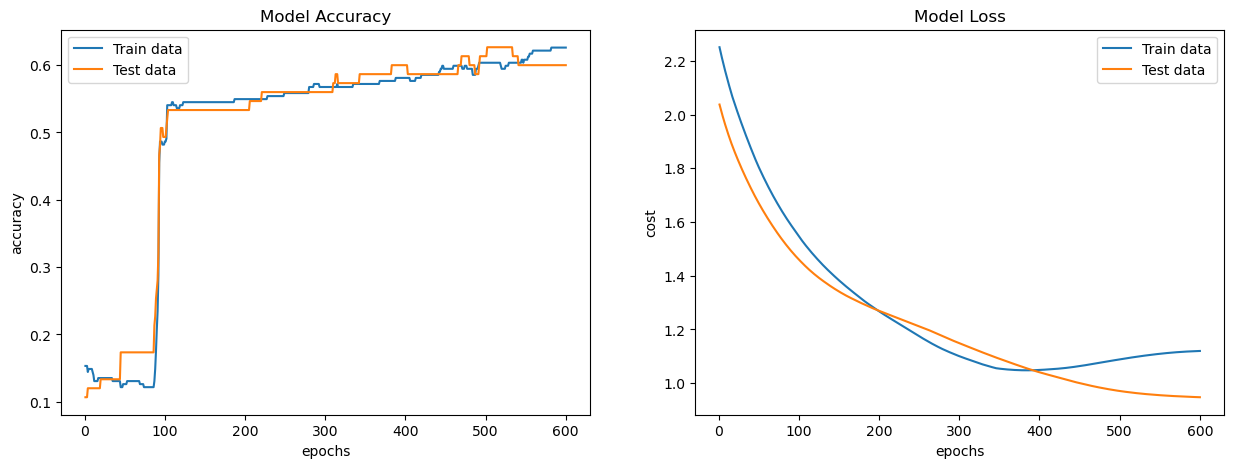

In [ ]:
## an OK neural network
model1_unfittted = build_model((8, 4, 2,), 0.09, 0.000056)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model1, epochs_model1, trainAccuracy_model1, testAccuracy_model1, trainCost_model1, testCost_model1 = train_model(model1_unfittted, 600, True)
plot_model(epochs_model1, trainAccuracy_model1, testAccuracy_model1, trainCost_model1, testCost_model1)

**At 0 - 80 epochs,**

There is clear underfitting (the model is too simple) shown by both the test and train data having high cost and very low accuracy.


**At 80 - 200 epochs,**

The accuracy suddenly spikes and the cost flattens out slightly, indicating that the model is close to a minimum and has increased in complexity. There is then little change in the accuracy of the test and training data, implying that convergence has been reached and that it has found a minimum in cost function. However, the accuracy is still quite low.


**At 200 to 300 epochs**

If continue to train the model, we see an increase in accuracy and that it flattens out again. The cost has also steadily decreased, implying that it has either become closer to the minimum or has found a different lower minimum of the cost function. The train and test cost is very close together still suggesting that the model hasn't overfitted (ovefitting is when the model is too senstive to the training data). Therefore, it would be best to stop the model at 300 epoch as it would be inefficient to continue training the model for only minor improvements.

**At 300+ epochs**

After 350 epochs we don't see any clear convergence and the train cost starts increasing suggesting that the model is now problematic and that it has skipped over the minimum of the loss function. So, we want to stop training at 300 epochs.

In [18]:
# results
print("\nResults:")
print("  Accuracy:", model1.score(X_test, y_test))
print("  Loss:", compute_cost(model1, X_test, y_test))

print("\nResults (At epoch 300):")
print("  Accuracy:", testAccuracy_model1[300])
print("  Loss:", testCost_model1[300])


Results:
  Accuracy: 0.6
  Loss: 0.9473723986013934

Results (At epoch 300):
  Accuracy: 0.56
  Loss: 1.1474260712336035


So in the end our optimised model has an accuracy of 0.56 (56%), if we stop at 300 epochs.

##### Changing Hidden Layers

Here we are going to look at the effect at changing the size and number of hidden layers, but with keeping the other parameters the same.

No. of pararmeters to learn:  13


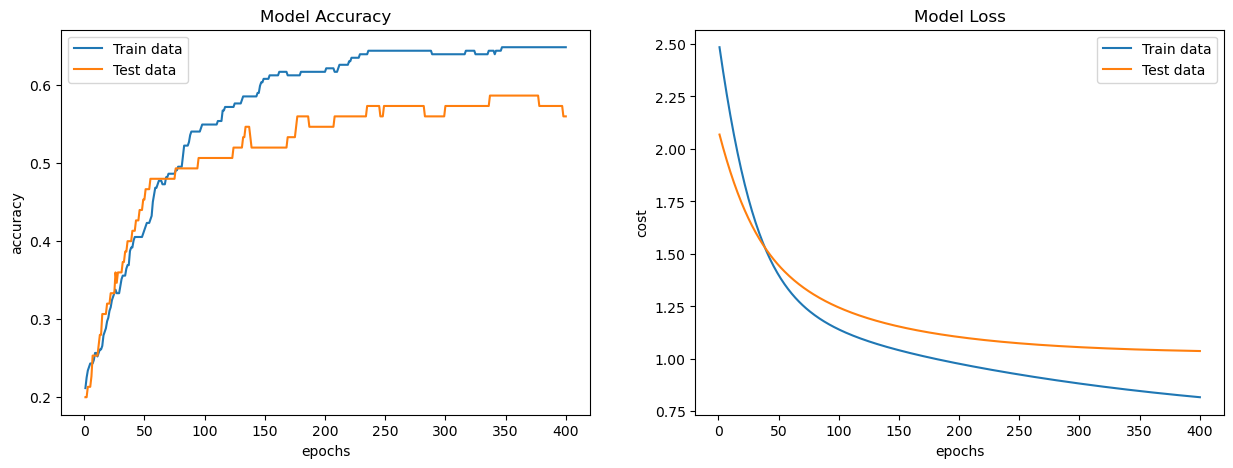

In [19]:
## no hidden layers
model2_unfittted = build_model((), 0.09, 0.000056)
print("No. of pararmeters to learn: ", (13*1))
model2, epochs_model2, trainAccuracy_model2, testAccuracy_model2, trainCost_model2, testCost_model2 = train_model(model2_unfittted, 400, False)
plot_model(epochs_model2, trainAccuracy_model2, testAccuracy_model2, trainCost_model2, testCost_model2)

We can see that by having no hidden layers then there are fewer parameters to learn so the cost of the test and training data flatterns early on (around 100 epochs). This is because it can find the minimum of the cost function a lot sooner. As we continue to train the model, we see slight overfitting, which is more clearly seen with the accuracy of the training data becoming significantly higher than the accuracy of the test data.

No. of pararmeters to learn:  2160


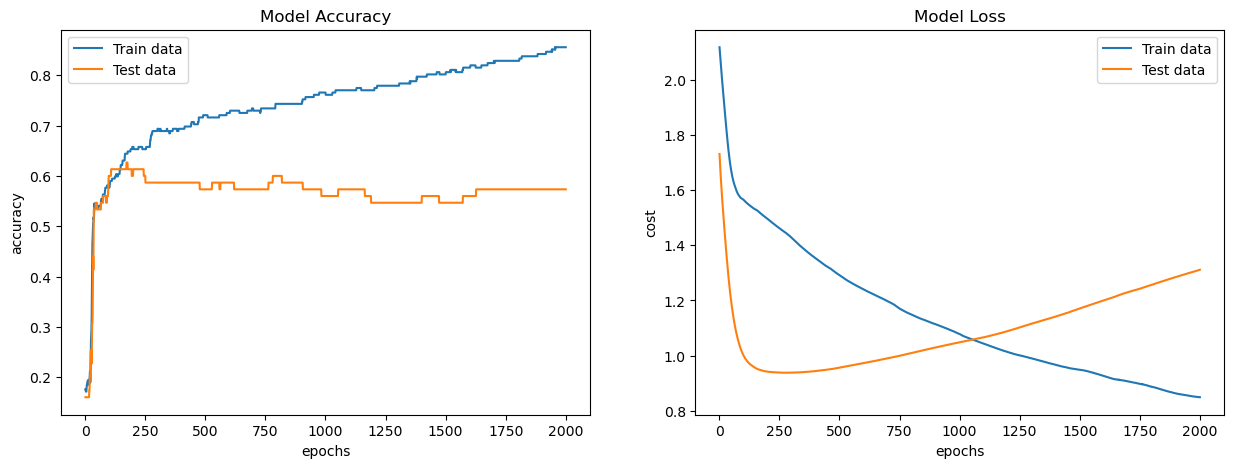

In [20]:
## large hidden layers
model3_unfittted = build_model((50, 25, 10), 0.09, 0.000056)
print("No. of pararmeters to learn: ", (13*50 + 50*25 + 25*10 + 10*1))
model3, epochs_model3, trainAccuracy_model3, testAccuracy_model3, trainCost_model3, testCost_model3 = train_model(model3_unfittted, 2000, False)
plot_model(epochs_model3, trainAccuracy_model3, testAccuracy_model3, trainCost_model3, testCost_model3)

We can see there is clear overfitting with this model. The accuracy of the training data continues to increase as the model 'memorises' the training data, meaning that the model is not general enough so has poor accuracy for the test data. Looking at the loss graph, the test and train costs are far apart and seperate, implying overfitting. Then also, the cost for the test data diverges, whilst the training data cost steadily decreases, showing again the significant overfitting.
Since there are 2160 weights to learn then it takes many iterations for the train cost decrease to a reasonable level and the large number of parameters causes the significant overfitting because the model becomes very specilised to the training data.

No. of pararmeters to learn:  292


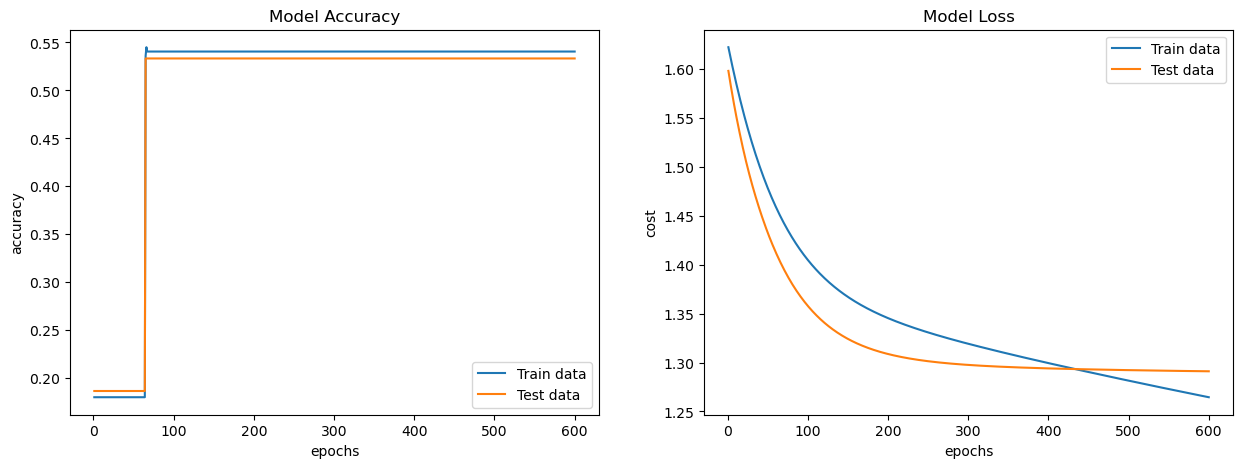

In [21]:
## lots of hidden layers
model4_unfittted = build_model((10, 8, 6, 4, 2), 0.09, 0.000056)
print("No. of pararmeters to learn: ", (13*10 + 10*8 + 8*6 + 6*4 +4*2 + 2*1))
model4, epochs_model4, trainAccuracy_model4, testAccuracy_model4, trainCost_model4, testCost_model4 = train_model(model4_unfittted, 600, False)
plot_model(epochs_model4, trainAccuracy_model4, testAccuracy_model4, trainCost_model4, testCost_model4)

Due to having lots of hidden layers, we get a very complex neural network. Looking at the accuracy graph, it is evident that the model learns very quickly but then stopped learning and didnt improve. The test and train accuracy is very simialr suggesting good generalisation, however, since it is not improving then we can assume that our neural network is too hard to learn due to lots of hidden layers. We can also see this in the cost graph, with the test data flattening out very quickly at quite a high cost and the training data decreasing quickly at the start and then slowly later on, suggesting that it is stuck in a cost minimum.

Hence, this is not a good model because it is too complex to train and may need its learning rate adjusted to compensate.

##### Changing the Learning Rate
Here we are going to look at how changing the learning rate affects the model.

No. of pararmeters to learn:  146


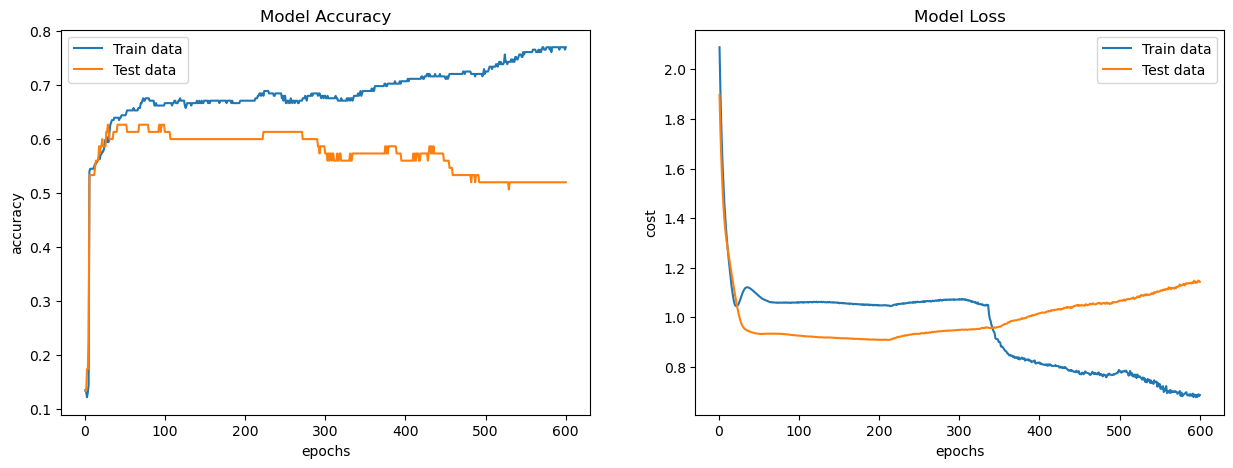

In [22]:
## 0.001 (higher) learning rate
model5_unfittted = build_model((8, 4, 2,), 0.09, 0.001)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model5, epochs_model5, trainAccuracy_model5, testAccuracy_model5, trainCost_model5, testCost_model5 = train_model(model5_unfittted, 600, False)
plot_model(epochs_model5, trainAccuracy_model5, testAccuracy_model5, trainCost_model5, testCost_model5)

There is clear overfitting here, shown though the train accuracy increasing and becoming significantly higher than the test accuracy as the model 'memorises' the training data. This is also shown in the loss graph, with the train and test data being seperate and as we continue to train the model past 200 epochs the test data diverges, compared to the train data which continues to decrease. We could suggest stopping the training at 200 epochs, where it seems to have converged, however, there is still a significant difference between test and train data implying overfitting.
The train data fluctates in both the accuracy and loss graphs, which is due to the learning rate being too big so it jumps around the minimum of the cost function. The drop at 350 epochs in the cost graph, suggests that a different lower minimum of the cost function was found, however, this does not generalise to the test data.

No. of pararmeters to learn:  146


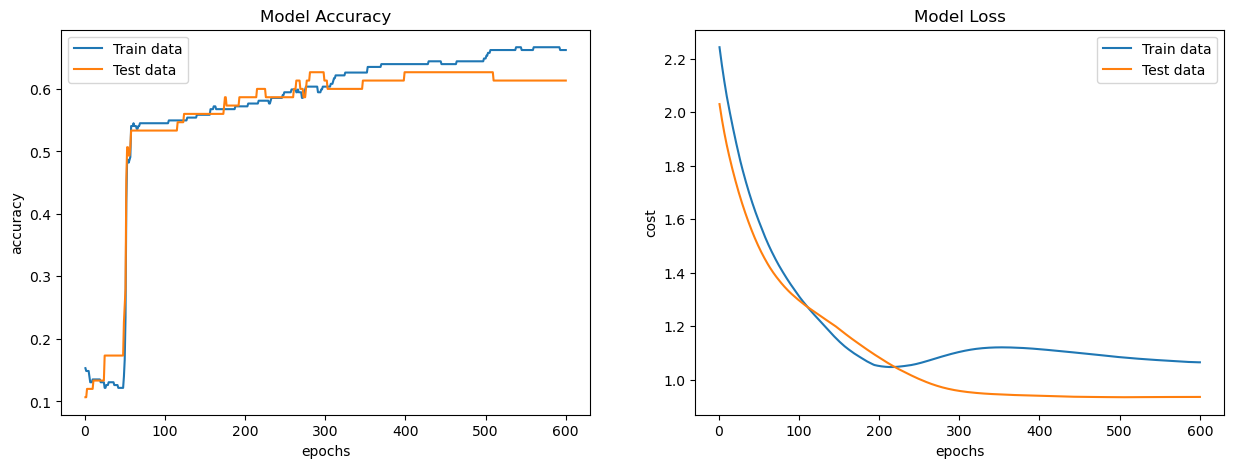

In [23]:
##  0.0001 (still higher) learning rate
model5_unfittted = build_model((8, 4, 2,), 0.09, 0.0001)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model5, epochs_model5, trainAccuracy_model5, testAccuracy_model5, trainCost_model5, testCost_model5 = train_model(model5_unfittted, 600, False)
plot_model(epochs_model5, trainAccuracy_model5, testAccuracy_model5, trainCost_model5, testCost_model5)

With a slighly lower learning rate (still higher than our optimised neural network), it takes longer for the model to converge (at 350+ epochs) and shows signs of overfitting after 300 epochs. From 0 to 250 epochs, the cost graphs looks good with the train and test data being simailar and the cost decreasing quickly. But when it converges, the test and train data have seperated, also shown slightly in the accuracy graph, implying that our model is overfitting.
The slight bump in the training data cost at 325 epochs could be due to it over shooting the minimum, which is likely a consequence of using a constant learning rate that is slightly too high.

No. of pararmeters to learn:  146


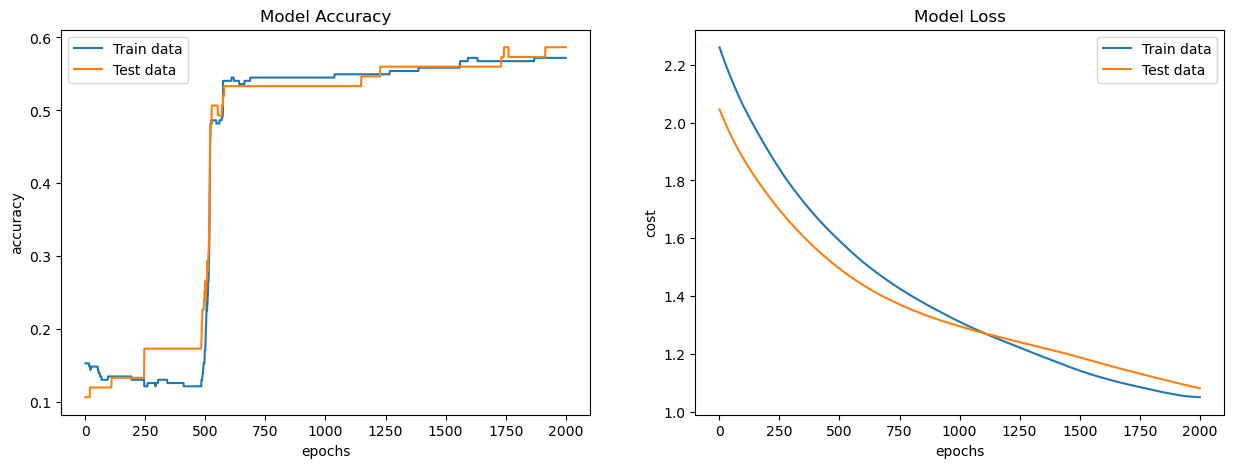

In [ ]:
##  0.00001 (lower) learning rate
model5_unfittted = build_model((8, 4, 2,), 0.09, 0.00001)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model5, epochs_model5, trainAccuracy_model5, testAccuracy_model5, trainCost_model5, testCost_model5 = train_model(model5_unfittted, 2000, False)
plot_model(epochs_model5, trainAccuracy_model5, testAccuracy_model5, trainCost_model5, testCost_model5)

From 0 to 500 epochs, the accuracy is very low and the cost of both the training and test data is high, implying the model is underfitting due to it being too simple/general. This is due to the learning rate being too small and hence taking too long to reach a minimum, which is inefficent. After 2000 iterations, it still hasn't converged, so it is too computationally intensive to use a small learning rate.

##### Changing Strength of Regularisation
Looking at the effect of changing the strength of the L2 regularisation on the model.



**What is regularisation?**

Cost Function:

$$J(W, b) = \frac{1}{n}\sum_{i=1}^n L(\hat{y}_i, y_i) + \frac{\alpha}{2n}\sum_{l=1}^L ||W^{[l]}||_F^2$$

where $\alpha||W^{[l]}||_F^2$ is L2 regularisation term, which is the $\alpha$ (the regularisation strength) times $||W^{[l]}||_F^2$ (the sum of all the weights of the matrix).

L is the number of hidden layers and W is the matrix between each layer 

The aim of this term is to penaliuze complex model and therefore prevent overfitting.



No. of pararmeters to learn:  146


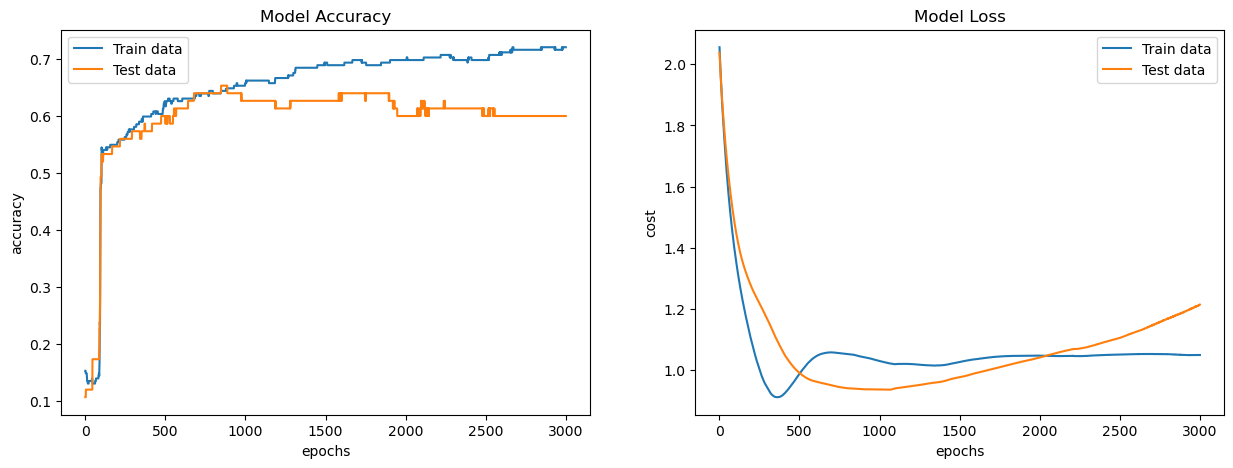

In [25]:
## 0.0001 (lower) regularisation stength
model6_unfittted = build_model((8, 4, 2,), 0.0001, 0.000056)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model6, epochs_model6, trainAccuracy_model6, testAccuracy_model6, trainCost_model6, testCost_model6 = train_model(model6_unfittted, 3000, False)
plot_model(epochs_model6, trainAccuracy_model6, testAccuracy_model6, trainCost_model6, testCost_model6)

From 0 to 1000 epochs, there is no convergence, although the training and test data cost both decrease quite steadily. But, they are not close to each other suggesting overfitting. Then after 1000 epochs it is very clear that it is overfitting with the test cost diverging. We could consider stopping training at 800 epochs, where the test data has flattened out, but we can see that the training data cost actually increases, which suggests that it has missed the minimum. So, the low cost for the test data could be due to randomness and therefore might not accurate on other unseen data.

Hence, low regularisation creates and overfitting model which does not seem to converge.

No. of pararmeters to learn:  146


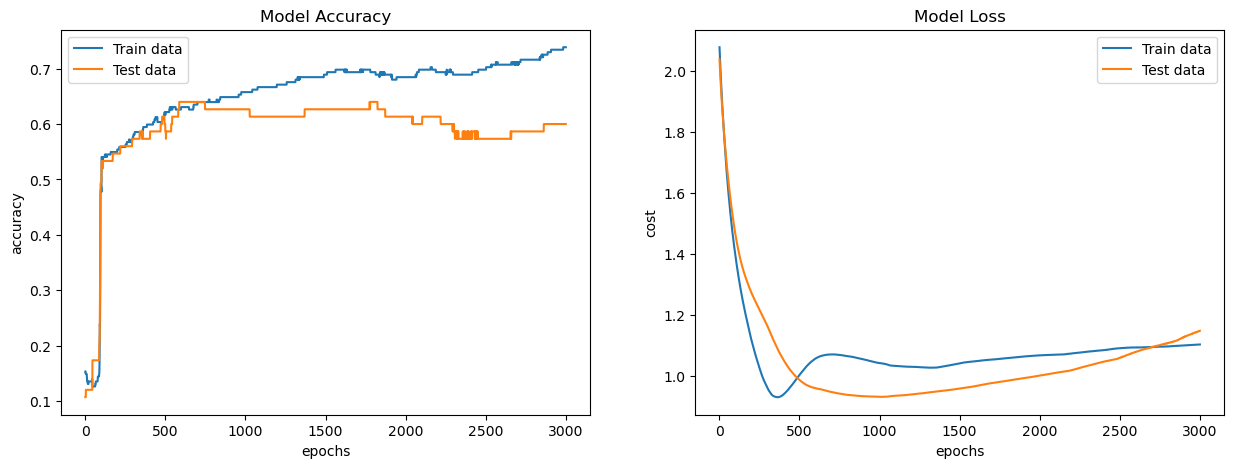

In [26]:
## 0.01 (slighly lower) regularisation stength
model7_unfittted = build_model((8, 4, 2,), 0.01, 0.000056)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model7, epochs_model7, trainAccuracy_model7, testAccuracy_model7, trainCost_model7, testCost_model7 = train_model(model7_unfittted, 3000, False)
plot_model(epochs_model7, trainAccuracy_model7, testAccuracy_model7, trainCost_model7, testCost_model7)

By using a slightly higher strength of regularisation compared to the previous model, it reduces how quickly the test cost diverges and hence, it reduces overfitting. Other than that this is still an overfitting model, which is similar to the one above.

No. of pararmeters to learn:  146


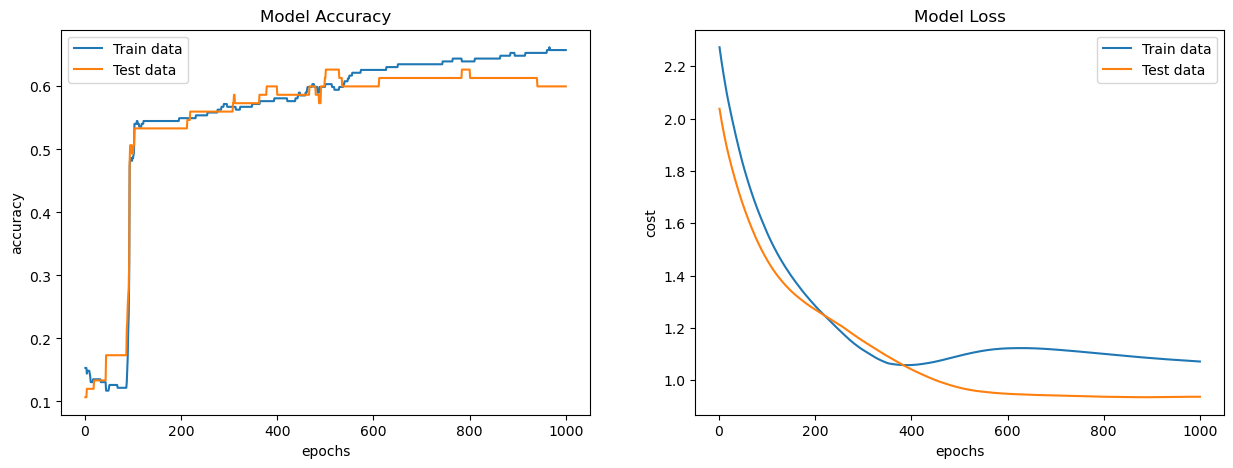

In [27]:
## 0.1 (slighly higher) regularisation stength
model8_unfittted = build_model((8, 4, 2,), 0.1, 0.000056)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model8, epochs_model8, trainAccuracy_model8, testAccuracy_model8, trainCost_model8, testCost_model8 = train_model(model8_unfittted, 1000, False)
plot_model(epochs_model8, trainAccuracy_model8, testAccuracy_model8, trainCost_model8, testCost_model8)

With a higher stength of regularisation, the test data cost follows the training data more closely from 0 to 400 epochs, which means that it isn't overfitting. After 400 epochs the test and training costs do seperate, but the test data does not diverge and is therefore showing less overfitting. We can also see that in the accuracy graph the test and training data are fairly close together even when it converges, showing less overfitting of the model. Although naturally training the data with lots of iterations does lead to overfitting which is what is presented here.

No. of pararmeters to learn:  146


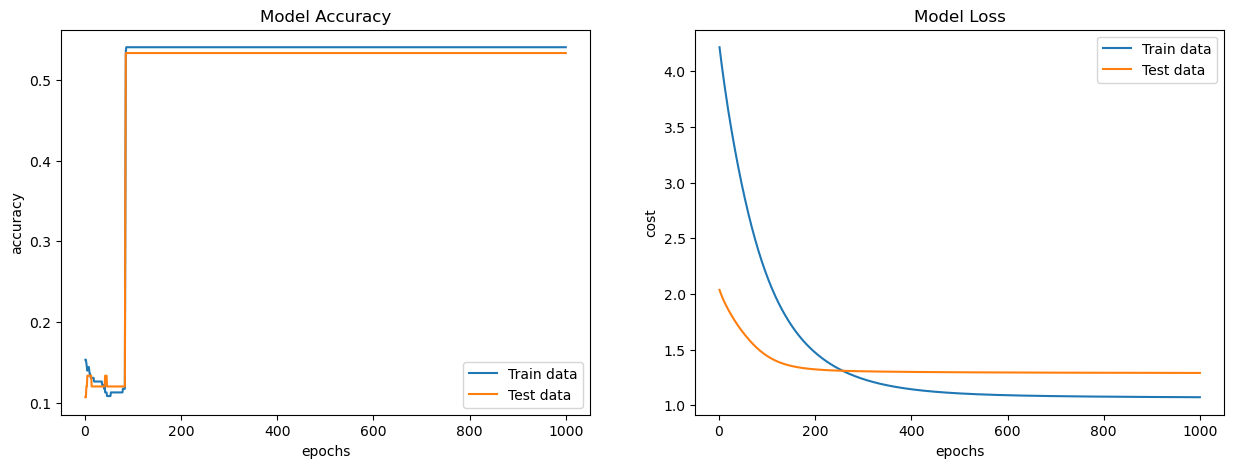

In [28]:
## 1.0 (higher) regularisation stength
model9_unfittted = build_model((8, 4, 2,), 1.0, 0.000056)
print("No. of pararmeters to learn: ", (13*8 + 8*4 + 4*2 + 2*1))
model9, epochs_model9, trainAccuracy_model9, testAccuracy_model9, trainCost_model9, testCost_model9 = train_model(model9_unfittted, 1000, False)
plot_model(epochs_model9, trainAccuracy_model9, testAccuracy_model9, trainCost_model9, testCost_model9)

With a very high strength of regularisation, the model is clearly underfitting due to the large weights and a complex model being penalised too much causing a very simple model. Therfore, we reach convergence at a low accuracy very quickly with a high cost, since the model has reached its capacity. Hence, this creates a model that is too general to be useful.

##### Conclusion

In conclusion, 

1. Having lots of hidden layers creates a naural network that is too complex to learn and then large hidden layers cause overfitting and due to lots of parameters needing to be learnt. Whereas, no hidden layers have too few parameters leading to underfitting.

2. By using a high learning rate, we reach convergence quicker but end up skipping over the minimum of the cost function. On the otherhand a low learning rate takes too long to find that minimum. Hence, adaptive learning rates might be more appropiate so that the model converges quickly but doesn't miss the minimum.

3. A low regularisation strength leads to an overfitting model, but if the regularisation strength is too high then a complex model is penalized too much causing an underfitting model that stops learning early on.

Another way we could improve this model is if we simplify it by converting the data into a binary classfication problem (heart disease or no heart disease) instead of having to classify the presence of heart disease between 0 and 4.

An example of using binary classification to improve this heart disease problem:
[Heart Disease Prediction using Neural Networks](https://www.kaggle.com/code/bulentsiyah/heart-disease-prediction-using-neural-networks/notebook)